## Mid-term Project: Bank Marketing Campaign Prediction

### Основна задача

У цьому проєкті розглядається задача бінарної класифікації: передбачення того, чи погодиться клієнт банку оформити строковий депозит після проведення маркетингової кампанії.

Метою є побудова ML-моделі, яка на основі характеристик клієнта, інформації про попередні контакти та соціально-економічних факторів може оцінити ймовірність позитивної відповіді клієнта.

Проєкт включає повний цикл розв'язання ML-задачі:

- аналіз та дослідження даних (EDA);
- формування гіпотез щодо впливу ознак;
- підготовку та трансформацію даних;
- створення нових ознак;
- навчання та порівняння декількох моделей;
- оптимізацію найкращої моделі;
- інтерпретацію результатів та аналіз помилок моделі.

### Бізнес-постановка задачі

Уявімо, що я працюю як Data Scientist у банківській сфері.

Перед маркетинговою командою стоїть задача ефективніше визначати клієнтів, які мають більшу ймовірність оформити строковий депозит.

Модель машинного навчання може допомогти:

- визначити найбільш перспективних клієнтів для контакту;
- оптимізувати маркетингові витрати;
- покращити персоналізацію пропозицій.

### Опис даних

Для роботи використовується датасет Bank Marketing Dataset, який містить інформацію про результати телефонних маркетингових кампаній португальського банку.

Дані включають:

- демографічні характеристики клієнтів;
- інформацію про фінансові продукти;
- параметри останнього контакту;
- результати попередніх маркетингових кампаній;
- макроекономічні показники.

Кінцева мета бінарної класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?

# Імпорти

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Train/validation split and model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# Metrics
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.metrics import ConfusionMatrixDisplay

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Boosting
from xgboost import XGBClassifier

# Hyperparameter optimization
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.model_selection import cross_val_score

from scipy.stats import uniform, randint
import shap

# Utilities
import time
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## Exploratory Data Analysis (EDA)

In [ ]:
raw_df = pd.read_csv("bank-additional-full.csv", sep=";")
raw_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
print(f"Dataset shape: {raw_df.shape}")

Dataset shape: (41188, 21)


In [ ]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
raw_df.describe(include="all")

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188,41188,41188,41188,41188,41188,41188,41188,41188,...,41188.000000,41188.000000,41188.000000,41188,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188
unique,NaN,12,4,8,3,3,3,2,10,5,...,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,2
top,NaN,admin.,married,university.degree,no,yes,no,cellular,may,thu,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,10422,24928,12168,32588,21576,33950,26144,13769,8623,...,NaN,NaN,NaN,35563,NaN,NaN,NaN,NaN,NaN,36548
mean,40.02406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.567593,962.475454,0.172963,NaN,0.081886,93.575664,-40.502600,3.621291,5167.035911,NaN
std,10.42125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.770014,186.910907,0.494901,NaN,1.570960,0.578840,4.628198,1.734447,72.251528,NaN
min,17.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN
25%,32.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN
50%,38.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,999.000000,0.000000,NaN,1.100000,93.749000,-41.800000,4.857000,5191.000000,NaN
75%,47.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN


In [ ]:
raw_df["y"].value_counts()

,count
y,
no,36548
yes,4640


In [ ]:
raw_df["y"].value_counts(normalize=True) * 100

,proportion
y,
no,88.734583
yes,11.265417


In [ ]:
raw_df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
raw_df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Датасет містить 41 188 спостережень та 21 змінну. Пропущені значення відсутні, тому окреме заповнення пропусків на етапі первинного препроцесингу не потрібне.

Цільова змінна y є незбалансованою: 88.73% клієнтів не оформили депозит і лише 11.27% погодилися. Через це accuracy не є оптимальною метрикою для оцінювання моделі, тому для подальшого порівняння моделей використовується AUROC.

Серед числових ознак є змінні з асиметричними розподілами та extreme values, зокрема duration, campaign та pdays. Особливу увагу необхідно приділити pdays, оскільки значення 999 має спеціальний зміст — клієнт раніше не контактувався.

Категоріальні ознаки містять інформацію про соціально-демографічні характеристики клієнта, його фінансовий стан та особливості маркетингового контакту. Потенційно важливими можуть бути job, education, contact, month, poutcome та інші.

Окремо необхідно врахувати ознаку duration. Вона може мати дуже сильний зв'язок із цільовою змінною, але її значення стає відомим лише після завершення дзвінка. Тому використання duration у фінальній predictive-моделі може призвести до data leakage. Надалі доцільно порівняти моделі з цією ознакою та без неї.

Також варто дослідити взаємозв'язки між економічними показниками (emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed) та перевірити їхній вплив на ймовірність оформлення депозиту.

## Початкові гіпотези дослідження

Перед проведенням аналізу даних були сформовані такі гіпотези щодо можливого впливу ознак на цільову змінну y:

1. Тривалість контакту (duration) - передбачається, що клієнти з більшою тривалістю контакту мають вищу ймовірність оформлення депозиту, оскільки довший контакт може свідчити про більшу зацікавленість клієнта.
2. Результат попередньої маркетингової кампанії (poutcome) - передбачається, що позитивний результат попередньої кампанії може бути сильним фактором впливу, оскільки клієнти, які вже проявляли інтерес до пропозиції, можуть частіше погоджуватися на депозит.
3. Соціально-демографічні характеристики (job, education, age) - передбачається, що характеристики клієнта можуть впливати на його фінансову поведінку та ймовірність оформлення депозиту.

## Аналіз впливу категоріальних ознак на цільову змінну

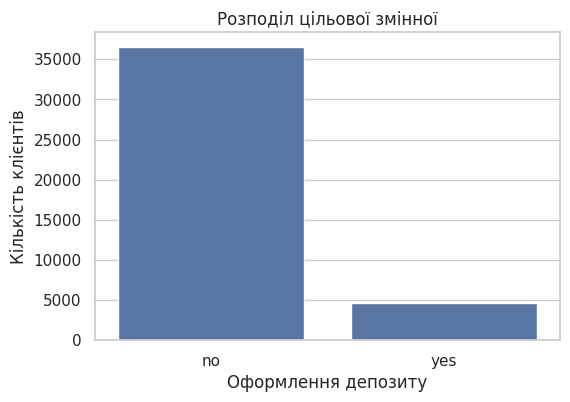

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=raw_df, x="y")
plt.title("Розподіл цільової змінної")
plt.xlabel("Оформлення депозиту")
plt.ylabel("Кількість клієнтів")
plt.show()

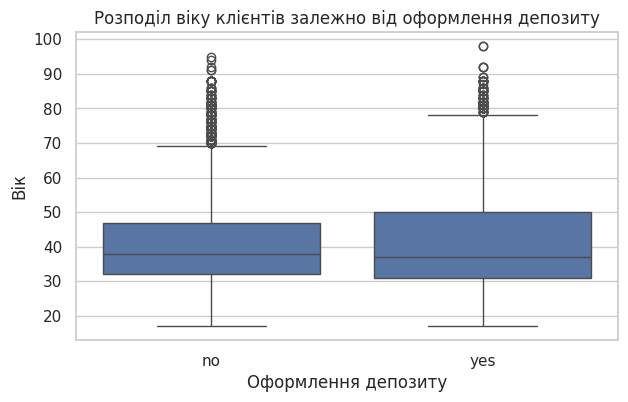

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=raw_df, x="y", y="age")
plt.title("Розподіл віку клієнтів залежно від оформлення депозиту")
plt.xlabel("Оформлення депозиту")
plt.ylabel("Вік")
plt.show()

Більшість клієнтів знаходяться у віковому діапазоні приблизно 30–60 років. Розподіл віку між класами yes і no відрізняється незначно. Вік може мати певний вплив на ймовірність оформлення депозиту, але, ймовірно, не буде єдиним визначальним фактором.

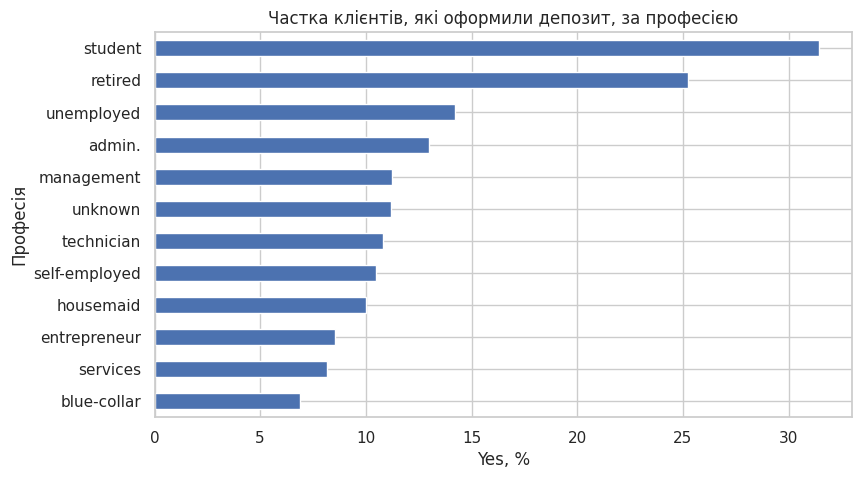

In [ ]:
job_rate = (
    raw_df.groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values()
)

plt.figure(figsize=(9, 5))
job_rate.plot(kind="barh")
plt.title("Частка клієнтів, які оформили депозит, за професією")
plt.xlabel("Yes, %")
plt.ylabel("Професія")
plt.show()

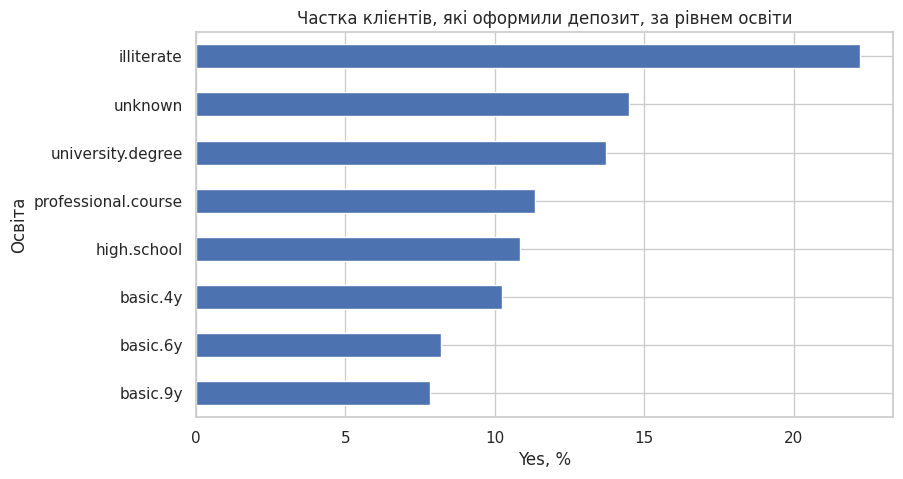

In [ ]:
education_rate = (
    raw_df.groupby("education")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values()
)

plt.figure(figsize=(9, 5))
education_rate.plot(kind="barh")
plt.title("Частка клієнтів, які оформили депозит, за рівнем освіти")
plt.xlabel("Yes, %")
plt.ylabel("Освіта")
plt.show()

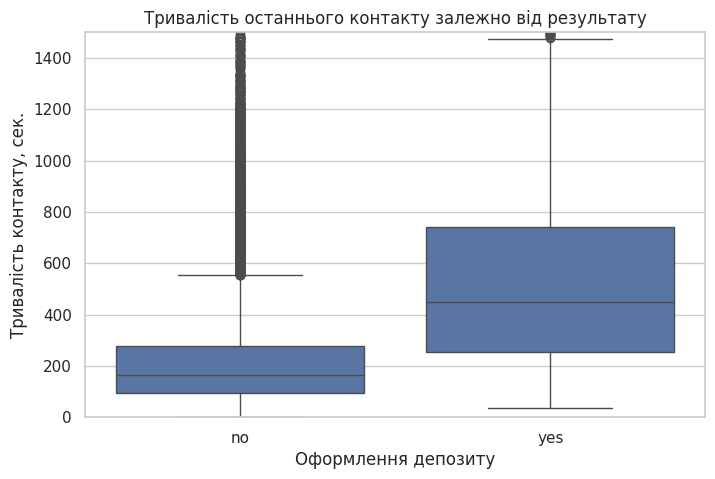

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=raw_df, x="y", y="duration")
plt.ylim(0, 1500)
plt.title("Тривалість останнього контакту залежно від результату")
plt.xlabel("Оформлення депозиту")
plt.ylabel("Тривалість контакту, сек.")
plt.show()

Клієнти, які погодились на депозит (yes), мають більшу середню тривалість контакту. Тривалість розмови може бути важливою ознакою, оскільки довший контакт може свідчити про більшу зацікавленість клієнта.

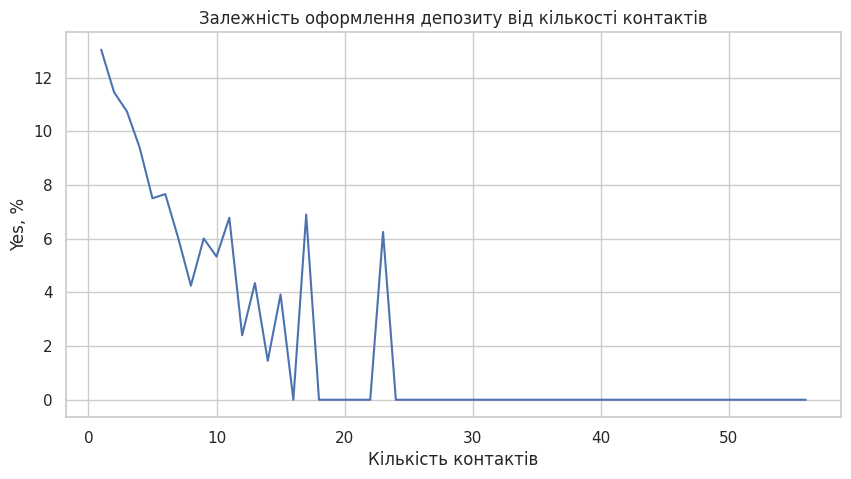

In [ ]:
campaign_rate = (
    raw_df.groupby("campaign")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
)

plt.figure(figsize=(10, 5))
campaign_rate.plot()
plt.title("Залежність оформлення депозиту від кількості контактів")
plt.xlabel("Кількість контактів")
plt.ylabel("Yes, %")
plt.show()

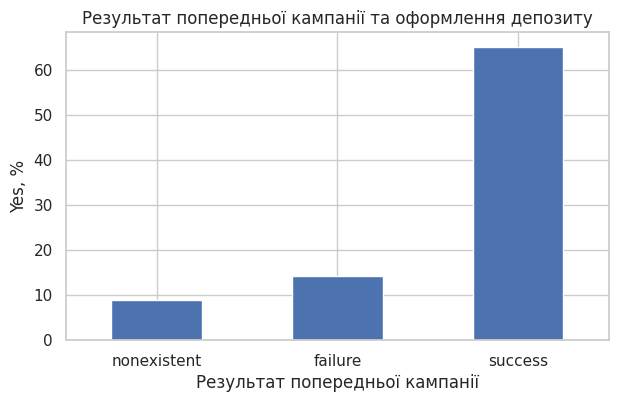

In [ ]:
poutcome_rate = (
    raw_df.groupby("poutcome")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values()
)

plt.figure(figsize=(7, 4))
poutcome_rate.plot(kind="bar")
plt.title("Результат попередньої кампанії та оформлення депозиту")
plt.xlabel("Результат попередньої кампанії")
plt.ylabel("Yes, %")
plt.xticks(rotation=0)
plt.show()

Клієнти з успішним результатом попередньої кампанії значно частіше погоджуються на депозит.

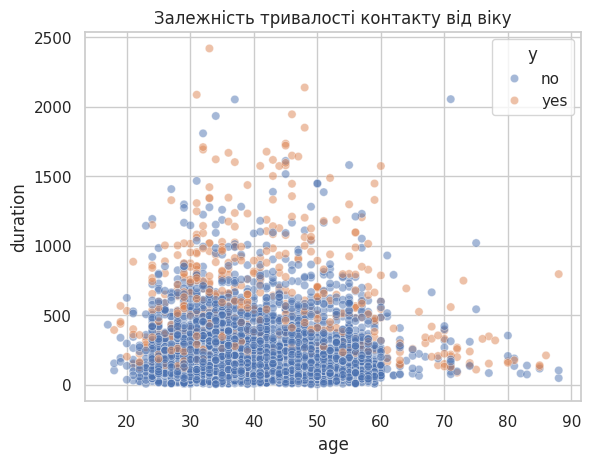

In [ ]:
sns.scatterplot(
    data=raw_df.sample(5000, random_state=42),
    x="age",
    y="duration",
    hue="y",
    alpha=0.5
)
plt.title("Залежність тривалості контакту від віку")
plt.show()

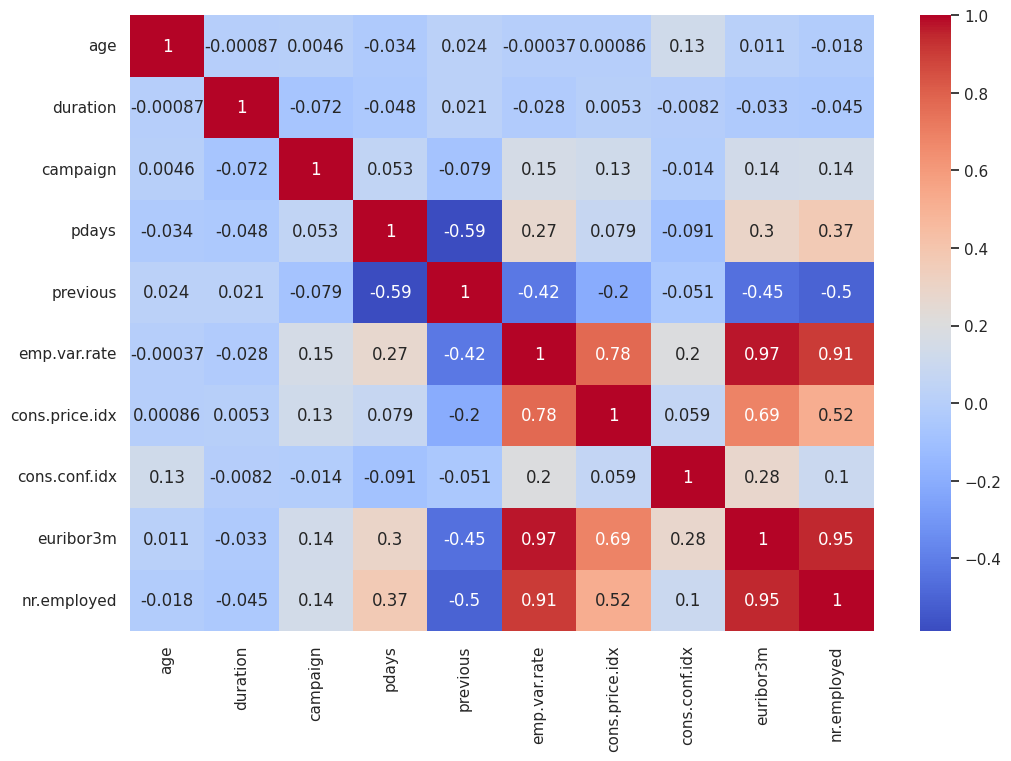

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    raw_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

### Висновок щодо кореляційного аналізу

Кореляційний аналіз показав, що більшість числових ознак мають слабкий лінійний зв'язок між собою.

Найсильніші кореляції спостерігаються між макроекономічними показниками:
- emp.var.rate та euribor3m (r ≈ 0.97)
- emp.var.rate та nr.employed (r ≈ 0.91)
- euribor3m та nr.employed (r ≈ 0.95)

Ці ознаки описують схожі економічні процеси, тому під час подальшого препроцесингу потрібно буде врахувати можливу мультиколінеарність.

## Аналіз категоріальних змінних

In [ ]:
categorical_cols = raw_df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print(raw_df[col].value_counts())


job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

contact
contact
ce

## Аналіз викидів

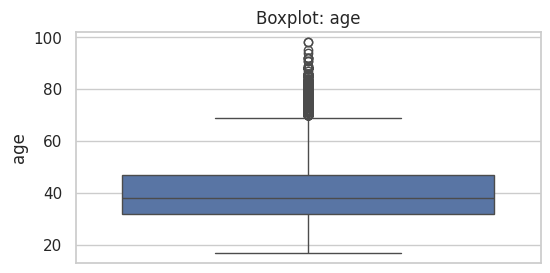

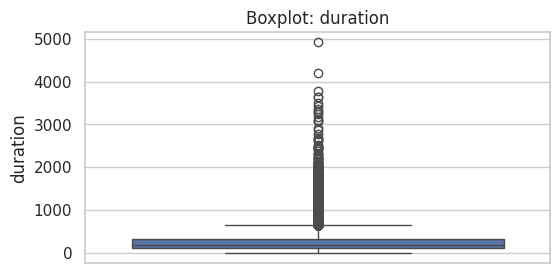

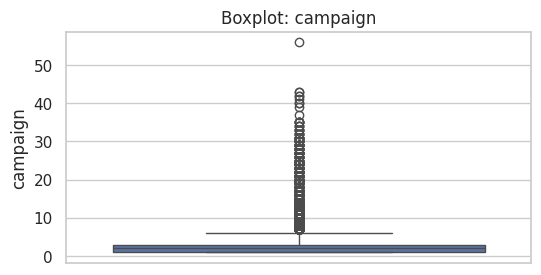

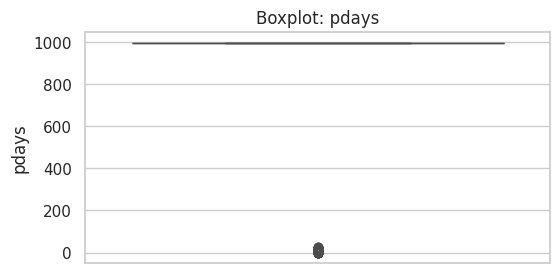

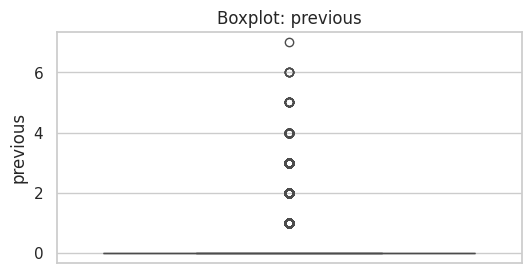

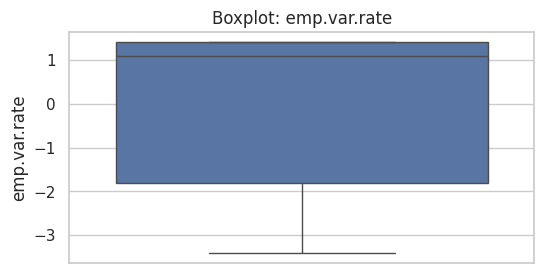

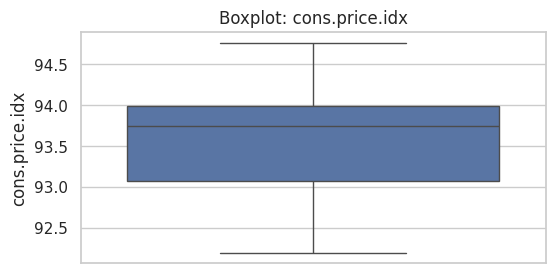

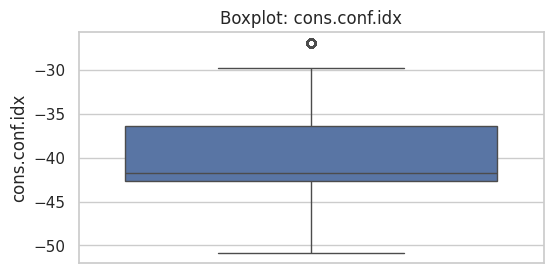

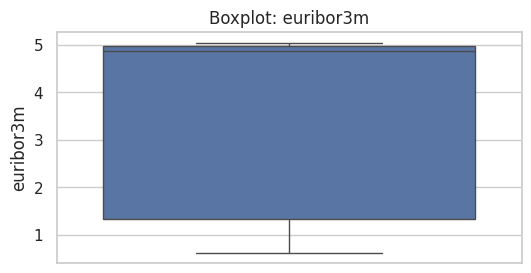

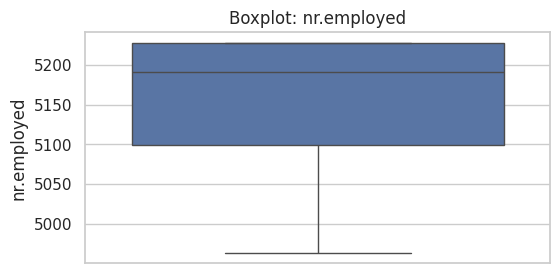

In [ ]:
numeric_cols = raw_df.select_dtypes(
    include=["int64", "float64"]
).columns

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(data=raw_df, y=col)
    plt.title(f"Boxplot: {col}")
    plt.show()

- високий вік клієнтів може відповідати реальним клієнтам банку;
- велика тривалість контакту може свідчити про зацікавленість клієнта;
- велика кількість контактів може відображати особливості маркетингової кампанії;
- значення pdays=999 є спеціальним позначенням відсутності попереднього контакту.

### Початкові гіпотези щодо впливу ознак на цільову змінну y

1. duration - передбачається позитивний вплив, оскільки довший контакт із клієнтом може свідчити про більшу зацікавленість.

2. poutcome - клієнти з успішним результатом попередньої кампанії мають більшу ймовірність оформлення депозиту.

3. job та education - соціально-демографічні характеристики можуть впливати на фінансову поведінку клієнта.

4. campaign - велика кількість контактів може мати негативний вплив через втому клієнта від повторних звернень.

# Вибір методів машинного навчання та метрик оцінки

### Logistic Regression

Logistic Regression буде використана як базова модель. Вона дозволяє отримати початкову оцінку якості та зрозуміти, наскільки добре лінійна модель може розділити два класи.

### Decision Tree

Decision Tree буде використана для перевірки можливості побудови нелінійних залежностей між ознаками та цільовою змінною. Перевагою моделі є простота інтерпретації результатів.

### k-Nearest Neighbors (kNN)

kNN використовується як модель, що базується на схожості об'єктів. Вона дозволяє перевірити, наскільки ефективно локальні залежності між клієнтами можуть використовуватись для класифікації.

### XGBoost

XGBoost буде використано як одна з основних моделей, оскільки градієнтний бустинг часто показує високі результати на структурованих табличних даних Модель здатна знаходити складні нелінійні залежності між ознаками.

## Вибір метрики оцінки якості

Оскільки цільова змінна має дисбаланс класів, використання лише accuracy може бути некоректним.

Наприклад, модель, яка завжди прогнозує негативний клас, може отримати високу accuracy, але не буде корисною для бізнес-задачі.

Тому основною метрикою буде використано ROC-AUC.

ROC-AUC показує, наскільки добре модель здатна розділяти позитивний та негативний класи незалежно від обраного порогу класифікації. Чим ближче значення ROC-AUC до 1, тим краще модель розрізняє клієнтів, які погодяться на депозит, і тих, хто відмовиться.

Додатково будуть розглянуті:

- Precision — наскільки часто позитивні прогнози моделі є правильними;
- Recall — яку частину реальних позитивних випадків модель змогла знайти;
- F1-score — баланс між precision та recall.

# Preprocessing даних

In [ ]:
df = raw_df.copy()

In [ ]:
df["y"] = df["y"].map({
    "yes": 1,
    "no": 0
})

In [ ]:
df["y"].value_counts()

,count
y,
0,36548
1,4640


На етапі підготовки даних було створено нові ознаки, які можуть містити додаткову інформацію про поведінку клієнтів.

Мета створення нових змінних — представити існуючі дані у більш інформативному вигляді для моделей машинного навчання.

##Feature engineering №1

In [ ]:
df["previous_contact"] = (
    df["pdays"] != 999
).astype(int)

In [ ]:
df["pdays"] = df["pdays"].replace(
    999,
    np.nan
)

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


У вихідному датасеті змінна `pdays` містить значення 999, яке означає відсутність попереднього контакту з клієнтом.

Оскільки це значення не є реальною кількістю днів, воно було замінене на пропущене значення.

Для збереження інформації про факт попередньої взаємодії було створено нову бінарну ознаку `previous_contact`:

- 0 — попереднього контакту не було;
- 1 — клієнт мав попередній контакт.

Таким чином модель отримує окрему інформацію про наявність попередньої взаємодії, а не сприймає 999 як числове значення.

##Feature engineering №2

In [ ]:
df["total_contacts"] = (
    df["campaign"] + df["previous"]
)

In [ ]:
df[["campaign", "previous", "total_contacts"]].head()

,campaign,previous,total_contacts
0,1,0,1
1,1,0,1
2,1,0,1
3,1,0,1
4,1,0,1


In [ ]:
df["total_contacts"] = (
    df["campaign"] + df["previous"]
)

In [ ]:
df[["campaign", "previous", "total_contacts"]].head()

,campaign,previous,total_contacts
0,1,0,1
1,1,0,1
2,1,0,1
3,1,0,1
4,1,0,1


Було створено нову ознаку `total_contacts`, яка відображає загальну кількість контактів із клієнтом.

Вона була розрахована як сума:

`campaign` + `previous`

де:
- `campaign` — кількість контактів під час поточної кампанії;
- `previous` — кількість контактів під час попередніх кампаній.

Гіпотеза полягає в тому, що загальна інтенсивність взаємодії банку з клієнтом може впливати на ймовірність оформлення депозиту.

##Feature engineering №3

In [ ]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 45, 60, 100],
    labels=[
        "young",
        "adult",
        "middle_age",
        "senior"
    ]
)

In [ ]:
df["age_group"].value_counts()

,count
age_group,
adult,21974
middle_age,10921
young,7383
senior,910


Було створено категоріальну ознаку `age_group` на основі віку клієнтів.

Клієнтів було розподілено на групи:

- young — до 30 років;
- adult — 30–45 років;
- middle_age — 45–60 років;
- senior — старше 60 років.

Створення цієї ознаки дозволяє моделі враховувати не тільки конкретний вік клієнта, а й приналежність до певної вікової групи.

Було створено додаткові ознаки:

- previous_contact_success
- customer_contact_frequency
- economic_condition_group

## Групування категорій у education

In [ ]:
df["education"] = df["education"].replace(
    {
        "basic.4y": "basic",
        "basic.6y": "basic",
        "basic.9y": "basic"
    }
)

In [ ]:
df["education"].value_counts()

,count
education,
basic,12513
university.degree,12168
high.school,9515
professional.course,5243
unknown,1731
illiterate,18


Категорії `basic.4y`, `basic.6y` та `basic.9y` були об'єднані у спільну категорію `basic`.

Ці категорії описують різні рівні базової освіти, тому їх об'єднання дозволяє зменшити кількість унікальних значень та уникнути зайвої деталізації під час кодування категоріальних змінних.

### Розділення ознак та цільової змінної

На цьому етапі датасет було розділено на:

- `X` — набір вхідних ознак, які використовуватиме модель;
- `y` — цільову змінну, яку модель повинна передбачити.

Цільова змінна `y` має бінарний формат:
- 0 — клієнт не погодився на депозит;
- 1 — клієнт погодився на депозит.

In [ ]:
X = df.drop("y", axis=1)
y = df["y"]

In [ ]:
X.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,previous_contact,total_contacts,age_group
0,56,housemaid,married,basic,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1,middle_age
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1,middle_age
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1,adult
3,40,admin.,married,basic,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1,adult
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1,middle_age


In [ ]:
y.head()

,y
0,0
1,0
2,0
3,0
4,0


### Визначення типів ознак

Перед побудовою моделей ознаки були розділені на дві групи:

1. Числові ознаки:
- будуть масштабовані за допомогою StandardScaler для моделей, чутливих до масштабу.

2. Категоріальні ознаки:
- будуть перетворені у числовий формат за допомогою OneHotEncoder.

In [ ]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric:")
print(numeric_features)

print("\nCategorical:")
print(categorical_features)

Numeric:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previous_contact', 'total_contacts']

Categorical:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'age_group']


## 1. Обробка числових ознак

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

## 2. Обробка категоріальних ознак

In [ ]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

## 3. Об'єднуємо все через ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

Такий підхід дозволяє застосовувати однакову схему обробки даних до різних ML-моделей та уникнути помилок під час підготовки тестових даних.

## Train/Test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
y_train.value_counts(normalize=True)

,proportion
y,
0,0.887344
1,0.112656


In [ ]:
y_test.value_counts(normalize=True)

,proportion
y,
0,0.887351
1,0.112649


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_train_processed.shape

(32950, 67)

Після трансформації тренувальна вибірка містить 32950 спостережень та 67 ознак.

# Logistic Regression

Першою моделлю для побудови baseline використаємо Logistic Regression.

Ця модель добре підходить для задач бінарної класифікації та дозволяє отримати інтерпретований базовий результат, з яким можна порівнювати складніші алгоритми.

In [ ]:
log_reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [ ]:
log_reg_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'previous_contact',
                                                   'total_contacts']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome',
                                                   'age_group'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
y_train_pred = log_reg_pipeline.predict(X_train)
y_test_pred = log_reg_pipeline.predict(X_test)

y_test_proba = log_reg_pipeline.predict_proba(X_test)[:,1]

In [ ]:
results = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1": f1_score(y_test, y_test_pred),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba)
}

results

{'Accuracy': 0.9164845836368051,
 'Precision': 0.7090592334494773,
 'Recall': 0.4385775862068966,
 'F1': 0.5419440745672437,
 'ROC-AUC': np.float64(0.9428823293551584)}

## Оцінка Logistic Regression

Першою моделлю було використано Logistic Regression як baseline модель.

Отримані результати:

- Accuracy: 91.65%
- Precision: 70.91%
- Recall: 43.86%
- F1-score: 54.19%
- ROC-AUC: 94.29%

Модель демонструє високу здатність розділяти класи, що підтверджується високим значенням ROC-AUC.

Водночас Recall залишається відносно невисоким, що означає, що модель пропускає частину клієнтів, які фактично могли б оформити депозит.

Для банківської задачі це може бути важливим, оскільки пропущені потенційні клієнти означають втрачені можливості маркетингового контакту.

# k-Nearest Neighbors (kNN)

Наступною моделлю використовується алгоритм k-Nearest Neighbors.

kNN використовується як модель порівняння.
Оскільки алгоритм базується на відстанях між об'єктами, для нього важливе масштабування числових ознак.

Модель буде навчена через той самий preprocessing pipeline, щоб уникнути відмінностей між підготовкою train та test даних.

In [ ]:
knn_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            KNeighborsClassifier(
                n_neighbors=5
            )
        )
    ]
)

In [ ]:
knn_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'previous_contact',
                                                   'total_contacts']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome',
                                                   'age_group'])])),
                ('model', KNeighborsClassifier())])

In [ ]:
y_test_pred_knn = knn_pipeline.predict(X_test)

y_test_proba_knn = knn_pipeline.predict_proba(X_test)[:,1]

In [ ]:
knn_results = {
    "Accuracy": accuracy_score(
        y_test,
        y_test_pred_knn
    ),

    "Precision": precision_score(
        y_test,
        y_test_pred_knn
    ),

    "Recall": recall_score(
        y_test,
        y_test_pred_knn
    ),

    "F1": f1_score(
        y_test,
        y_test_pred_knn
    ),

    "ROC-AUC": roc_auc_score(
        y_test,
        y_test_proba_knn
    )
}


knn_results

{'Accuracy': 0.9072590434571498,
 'Precision': 0.6265432098765432,
 'Recall': 0.4375,
 'F1': 0.5152284263959391,
 'ROC-AUC': np.float64(0.8774301706448417)}

### Оцінка k-Nearest Neighbors (kNN)

Модель kNN показала наступні результати:

- Accuracy: 90.73%
- Precision: 62.65%
- Recall: 43.75%
- F1-score: 51.52%
- ROC-AUC: 87.74%

Порівняно з Logistic Regression модель показала нижчу здатність розділяти класи, що видно за меншим значенням ROC-AUC.

Також Recall залишається низьким, тому модель пропускає значну частину клієнтів, які могли б оформити депозит.

Для задачі банківського маркетингу це означає втрату потенційних клієнтів, тому kNN не є оптимальним вибором для фінального рішення.

# Decision Tree

In [ ]:
dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

In [ ]:
dt_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'previous_contact',
                                                   'total_contacts']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome',
                                                   'age_group'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [ ]:
y_test_pred_dt = dt_pipeline.predict(X_test)

y_test_proba_dt = dt_pipeline.predict_proba(X_test)[:,1]

In [ ]:
dt_results = {
    "Accuracy": accuracy_score(y_test, y_test_pred_dt),
    "Precision": precision_score(y_test, y_test_pred_dt),
    "Recall": recall_score(y_test, y_test_pred_dt),
    "F1": f1_score(y_test, y_test_pred_dt),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_dt)
}

dt_results

{'Accuracy': 0.8953629521728574,
 'Precision': 0.5352564102564102,
 'Recall': 0.5398706896551724,
 'F1': 0.5375536480686696,
 'ROC-AUC': np.float64(0.7401815828576819)}

### Оцінка Decision Tree

Decision Tree показала:

- Accuracy: 89.54%
- Precision: 53.53%
- Recall: 53.99%
- F1-score: 53.76%
- ROC-AUC: 74.02%

Модель має кращий Recall порівняно з kNN, однак значно поступається іншим моделям за ROC-AUC.

Низька здатність до узагальнення може бути пов'язана з тим, що одне дерево схильне до перенавчання.

# XGBoost

Для задачі класифікації використовується XGBoost — алгоритм градієнтного бустингу на основі дерев рішень. Його перевагою є здатність знаходити складні нелінійні залежності між ознаками та висока якість на табличних даних.

In [ ]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

In [ ]:
xgb_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'previous_contact',
                                                   'total_contacts']),
                                                 ('cat',
                                                  Pipeline(steps=[('imp...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
y_test_pred_xgb = xgb_pipeline.predict(X_test)

y_test_proba_xgb = xgb_pipeline.predict_proba(X_test)[:,1]

In [ ]:
xgb_results = {
    "Accuracy": accuracy_score(y_test, y_test_pred_xgb),
    "Precision": precision_score(y_test, y_test_pred_xgb),
    "Recall": recall_score(y_test, y_test_pred_xgb),
    "F1": f1_score(y_test, y_test_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_xgb)
}

xgb_results

{'Accuracy': 0.917941247875698,
 'Precision': 0.655940594059406,
 'Recall': 0.5711206896551724,
 'F1': 0.6105990783410138,
 'ROC-AUC': np.float64(0.9493708429642909)}

### Оцінка XGBoost

Отримані результати:

- Accuracy: 91.79%
- Precision: 65.59%
- Recall: 57.11%
- F1-score: 61.06%
- ROC-AUC: 94.94%

Серед базових моделей XGBoost показала найкращу якість прогнозування.

Порівняно з Logistic Regression та kNN модель краще знаходить нелінійні залежності між ознаками та має вищі значення ROC-AUC і F1-score.

Водночас модель все ще допускає False Negative помилки, тому наступним кроком буде оптимізація гіперпараметрів.

# Порівняння базових моделей

Після попереднього навчання моделей було отримано базові результати.
Найкращі показники показала модель XGBoost, тому подальший тюнінг гіперпараметрів буде виконано саме для неї.

In [ ]:
models_results = pd.DataFrame({
    "Logistic Regression": results,
    "kNN": knn_results,
    "Decision Tree": dt_results,
    "XGBoost": xgb_results
}).T

models_results

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.916485,0.709059,0.438578,0.541944,0.942882
kNN,0.907259,0.626543,0.437500,0.515228,0.877430
Decision Tree,0.895363,0.535256,0.539871,0.537554,0.740182
XGBoost,0.917941,0.655941,0.571121,0.610599,0.949371


## Налаштування гіперпараметрів XGBoost

Для покращення якості моделі виконаємо пошук оптимальних параметрів двома методами:

- RandomizedSearchCV з бібліотеки sklearn
- Bayesian Optimization за допомогою Hyperopt

In [ ]:
xgb_params = {
    "model__n_estimators": randint(100, 500),
    "model__max_depth": randint(3, 10),
    "model__learning_rate": uniform(0.01, 0.2),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4)
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['age',
                                                                                'duration',
                                                                                'campaign',
                                                                                'pdays',
                                                                                'previous',
                                                                                'emp.var.rate',
                                                                                'cons.price.idx',
                                                                                'cons.conf.idx',
                                                                                'euribor3m',
                                                                                'nr.employed',
                                                                                'previous_contact',
                                                                                'total_contac...
                                        'model__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b1f5446c050>,
                                        'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b1f95607100>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b1f47d1f610>,
                                        'model__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b1f5446d0f0>},
                   random_state=42, scoring='roc_auc')

In [ ]:
random_search.best_params_

{'model__colsample_bytree': np.float64(0.7599443886861021),
 'model__learning_rate': np.float64(0.019333132642723086),
 'model__max_depth': 6,
 'model__n_estimators': 370,
 'model__subsample': np.float64(0.7824279936868144)}

In [ ]:
random_search.best_score_

np.float64(0.9481118176322901)

In [ ]:
best_xgb = random_search.best_estimator_

y_test_pred_best = best_xgb.predict(X_test)
y_test_proba_best = best_xgb.predict_proba(X_test)[:,1]

In [ ]:
best_xgb_results = {
    "Accuracy": accuracy_score(y_test, y_test_pred_best),
    "Precision": precision_score(y_test, y_test_pred_best),
    "Recall": recall_score(y_test, y_test_pred_best),
    "F1": f1_score(y_test, y_test_pred_best),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_best)
}

best_xgb_results

{'Accuracy': 0.9253459577567371,
 'Precision': 0.7089452603471295,
 'Recall': 0.572198275862069,
 'F1': 0.6332737030411449,
 'ROC-AUC': np.float64(0.955999914500684)}

## Результати RandomizedSearchCV

Після оптимізації гіперпараметрів XGBoost модель показала покращення якості порівняно з базовою версією.

Налаштована модель має вищі значення ROC-AUC та F1-score, що свідчить про краще розділення класів та більш збалансоване прогнозування позитивного класу.

## Hyperopt Bayesian Optimization

Другий підхід до пошуку оптимальних гіперпараметрів виконаємо за допомогою бібліотеки Hyperopt, яка використовує Bayesian Optimization для ефективнішого пошуку параметрів моделі.

In [ ]:
space = {
    "model__n_estimators": hp.quniform(
        "n_estimators",
        100,
        500,
        50
    ),

    "model__max_depth": hp.quniform(
        "max_depth",
        3,
        10,
        1
    ),

    "model__learning_rate": hp.uniform(
        "learning_rate",
        0.01,
        0.2
    ),

    "model__subsample": hp.uniform(
        "subsample",
        0.6,
        1
    ),

    "model__colsample_bytree": hp.uniform(
        "colsample_bytree",
        0.6,
        1
    )
}

In [ ]:
def objective(params):

    params["model__n_estimators"] = int(
        params["model__n_estimators"]
    )

    params["model__max_depth"] = int(
        params["model__max_depth"]
    )

    model = xgb_pipeline.set_params(**params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return {
        "loss": -score,
        "status": STATUS_OK
    }

In [ ]:
trials = Trials()

best_params = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=30,
    trials=trials,
    rstate=np.random.default_rng(42)
)

best_params

100%|██████████| 30/30 [06:42<00:00, 13.41s/trial, best loss: -0.9479890223505262]


{'colsample_bytree': np.float64(0.7599792887894301),
 'learning_rate': np.float64(0.033507738063382364),
 'max_depth': np.float64(6.0),
 'n_estimators': np.float64(200.0),
 'subsample': np.float64(0.7646481947025827)}

In [ ]:
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["max_depth"] = int(best_params["max_depth"])

best_hyperopt_xgb = xgb_pipeline.set_params(
    **{
        "model__n_estimators": best_params["n_estimators"],
        "model__max_depth": best_params["max_depth"],
        "model__learning_rate": best_params["learning_rate"],
        "model__subsample": best_params["subsample"],
        "model__colsample_bytree": best_params["colsample_bytree"]
    }
)

In [ ]:
best_hyperopt_xgb.fit(
    X_train,
    y_train
)

y_test_pred_hyperopt = best_hyperopt_xgb.predict(X_test)

y_test_proba_hyperopt = best_hyperopt_xgb.predict_proba(X_test)[:,1]

In [ ]:
hyperopt_results = {
    "Accuracy": accuracy_score(
        y_test,
        y_test_pred_hyperopt
    ),
    "Precision": precision_score(
        y_test,
        y_test_pred_hyperopt
    ),
    "Recall": recall_score(
        y_test,
        y_test_pred_hyperopt
    ),
    "F1": f1_score(
        y_test,
        y_test_pred_hyperopt
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_test_proba_hyperopt
    )
}

hyperopt_results

{'Accuracy': 0.9243748482641417,
 'Precision': 0.7030625832223701,
 'Recall': 0.5689655172413793,
 'F1': 0.6289458010720667,
 'ROC-AUC': np.float64(0.9559858365960658)}

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "kNN",
        "Decision Tree",
        "XGBoost",
        "XGBoost RandomizedSearch",
        "XGBoost Hyperopt"
    ],
    "Accuracy": [
        results["Accuracy"],
        knn_results["Accuracy"],
        dt_results["Accuracy"],
        xgb_results["Accuracy"],
        best_xgb_results["Accuracy"],
        hyperopt_results["Accuracy"]
    ],
    "Precision": [
        results["Precision"],
        knn_results["Precision"],
        dt_results["Precision"],
        xgb_results["Precision"],
        best_xgb_results["Precision"],
        hyperopt_results["Precision"]
    ],
    "Recall": [
        results["Recall"],
        knn_results["Recall"],
        dt_results["Recall"],
        xgb_results["Recall"],
        best_xgb_results["Recall"],
        hyperopt_results["Recall"]
    ],
    "F1": [
        results["F1"],
        knn_results["F1"],
        dt_results["F1"],
        xgb_results["F1"],
        best_xgb_results["F1"],
        hyperopt_results["F1"]
    ],
    "ROC-AUC": [
        results["ROC-AUC"],
        knn_results["ROC-AUC"],
        dt_results["ROC-AUC"],
        xgb_results["ROC-AUC"],
        best_xgb_results["ROC-AUC"],
        hyperopt_results["ROC-AUC"]
    ]
})

model_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
4,XGBoost RandomizedSearch,0.925346,0.708945,0.572198,0.633274,0.956000
5,XGBoost Hyperopt,0.924375,0.703063,0.568966,0.628946,0.955986
3,XGBoost,0.917941,0.655941,0.571121,0.610599,0.949371
0,Logistic Regression,0.916485,0.709059,0.438578,0.541944,0.942882
1,kNN,0.907259,0.626543,0.437500,0.515228,0.877430
2,Decision Tree,0.895363,0.535256,0.539871,0.537554,0.740182


In [ ]:
train_scores = {
    "Logistic Regression": roc_auc_score(y_train, log_reg_pipeline.predict_proba(X_train)[:,1]),
    "kNN": roc_auc_score(y_train, knn_pipeline.predict_proba(X_train)[:,1]),
    "Decision Tree": roc_auc_score(y_train, dt_pipeline.predict_proba(X_train)[:,1]),
    "XGBoost": roc_auc_score(y_train, xgb_pipeline.predict_proba(X_train)[:,1]),
    "XGBoost RandomizedSearch": roc_auc_score(y_train, random_search.predict_proba(X_train)[:,1]),
    "XGBoost Hyperopt": roc_auc_score(y_train, best_xgb.predict_proba(X_train)[:,1])
}

train_scores

{'Logistic Regression': np.float64(0.9348799116820103),
 'kNN': np.float64(0.9622120014680352),
 'Decision Tree': np.float64(1.0),
 'XGBoost': np.float64(0.9651473301896917),
 'XGBoost RandomizedSearch': np.float64(0.9656769508371839),
 'XGBoost Hyperopt': np.float64(0.9656769508371839)}

In [ ]:
comparison_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "kNN",
        "Decision Tree",
        "XGBoost",
        "XGBoost RandomizedSearch",
        "XGBoost Hyperopt"
    ],

    "Hyperparameters": [
        "Default parameters",
        "n_neighbors = tuned value",
        "Default parameters",
        "Default parameters",
        str(random_search.best_params_),
        str(best_params)
    ],

    "Validation ROC-AUC": [
        results["ROC-AUC"],
        knn_results["ROC-AUC"],
        dt_results["ROC-AUC"],
        xgb_results["ROC-AUC"],
        best_xgb_results["ROC-AUC"],
        hyperopt_results["ROC-AUC"]
    ],

    "Comment": [
        "Baseline model. Simple and interpretable.",
        "Lower performance because distance-based methods are sensitive to data structure.",
        "Can capture nonlinear relationships but tends to overfit.",
        "Strong model with good performance.",
        "Improved after hyperparameter tuning.",
        "Best optimization approach, stable performance."
    ]
})


comparison_table.sort_values(
    by="Validation ROC-AUC",
    ascending=False
)

,Model,Hyperparameters,Validation ROC-AUC,Comment
4,XGBoost RandomizedSearch,{'model__colsample_bytree': np.float64(0.75994...,0.956000,Improved after hyperparameter tuning.
5,XGBoost Hyperopt,{'colsample_bytree': np.float64(0.759979288789...,0.955986,"Best optimization approach, stable performance."
3,XGBoost,Default parameters,0.949371,Strong model with good performance.
0,Logistic Regression,Default parameters,0.942882,Baseline model. Simple and interpretable.
1,kNN,n_neighbors = tuned value,0.877430,Lower performance because distance-based metho...
2,Decision Tree,Default parameters,0.740182,Can capture nonlinear relationships but tends ...


# Confusion Matrix

Для додаткового аналізу помилок моделей використаємо confusion matrix.

Вона дозволяє побачити кількість:
- True Negative - правильно визначені клієнти, які не відкрили депозит;
- True Positive - правильно визначені клієнти, які відкрили депозит;
- False Positive - клієнти, яким модель помилково передбачила депозит;
- False Negative - клієнти, які відкрили депозит, але модель цього не передбачила.

У задачах маркетингового прогнозування особливо важливо аналізувати False Negative, оскільки це потенційні клієнти, яких банк міг втратити через неправильне передбачення.

<Figure size 1500x1000 with 0 Axes>

<Figure size 400x300 with 0 Axes>

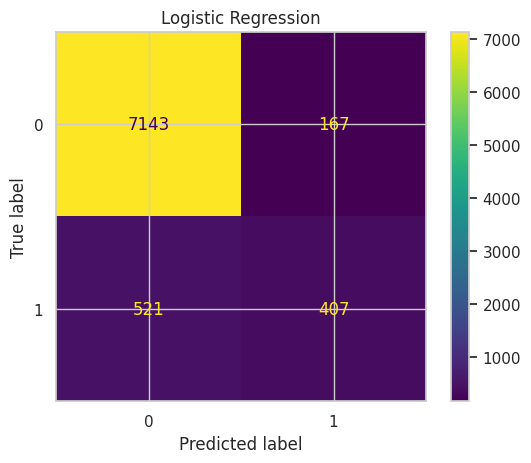

<Figure size 400x300 with 0 Axes>

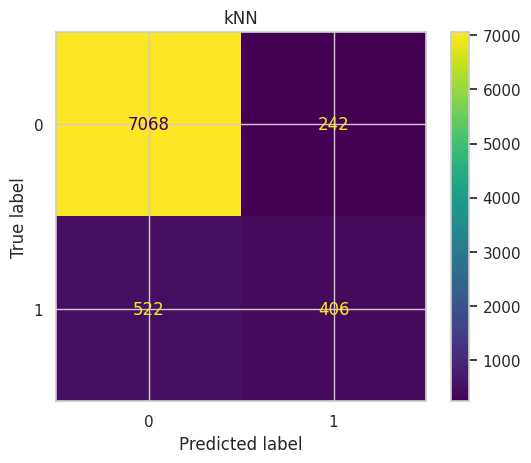

<Figure size 400x300 with 0 Axes>

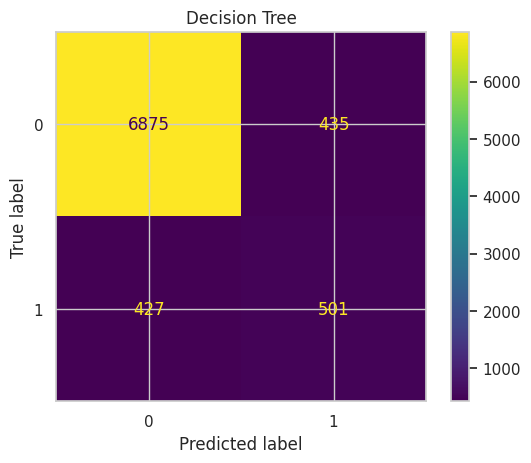

<Figure size 400x300 with 0 Axes>

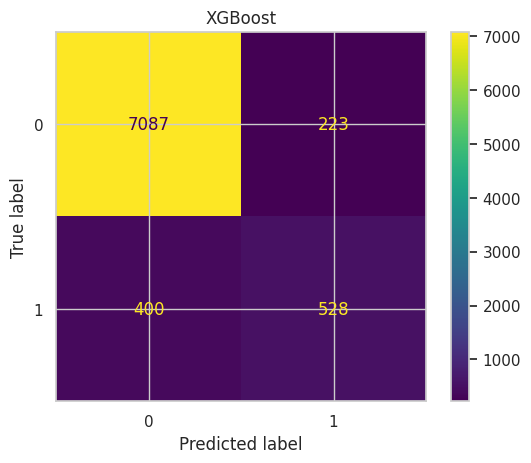

<Figure size 400x300 with 0 Axes>

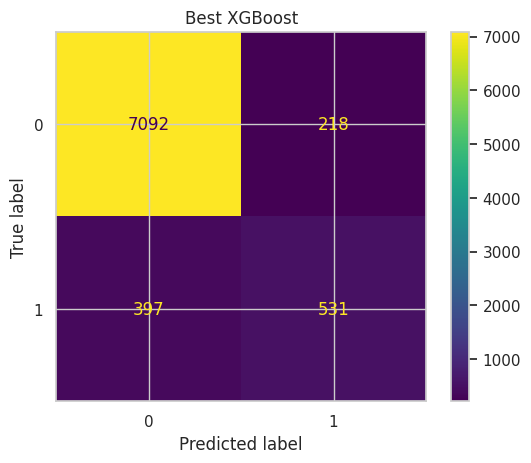

In [ ]:
models = {
    "Logistic Regression": log_reg_pipeline,
    "kNN": knn_pipeline,
    "Decision Tree": dt_pipeline,
    "XGBoost": xgb_pipeline,
    "Best XGBoost": random_search.best_estimator_
}

plt.figure(figsize=(15, 10))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)

    plt.figure(figsize=(4,3))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred
    )
    plt.title(name)
    plt.show()

## Порівняння моделей

Найкращий результат показала модель XGBoost після оптимізації гіперпараметрів.

RandomizedSearchCV та Hyperopt дали майже однаковий результат за метрикою ROC-AUC (~0.956), що свідчить про стабільність моделі після налаштування параметрів.

Порівняно з базовою моделлю XGBoost, оптимізація дозволила покращити якість прогнозування.

Decision Tree та kNN показали нижчі результати, тому для цієї задачі вони є менш ефективними.

## Feature Importance

Для найкращої моделі XGBoost було проаналізовано важливість ознак.

Feature importance показує, які ознаки найбільше вплинули на рішення моделі під час класифікації клієнтів.

In [ ]:
xgb_model = best_xgb.named_steps["model"]
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()


importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})


importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)


importance_df.head(15)

,Feature,Importance
9,num__nr.employed,0.334675
1,num__duration,0.069358
5,num__emp.var.rate,0.045459
10,num__previous_contact,0.035902
7,num__cons.conf.idx,0.029182
53,cat__month_oct,0.026969
51,cat__month_may,0.025881
8,num__euribor3m,0.025420
62,cat__poutcome_success,0.025214
45,cat__month_apr,0.020168


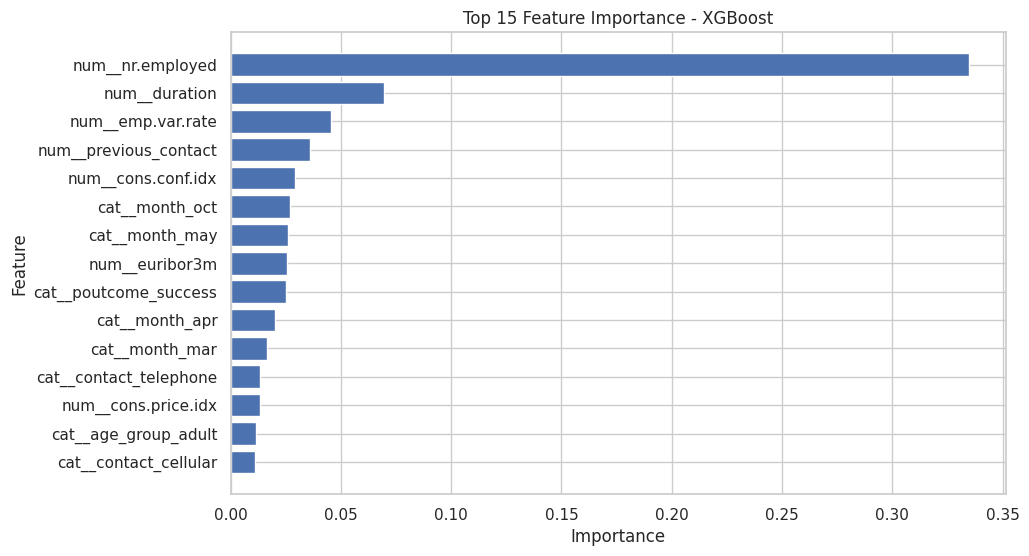

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df.head(15)["Feature"][::-1],
    importance_df.head(15)["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - XGBoost")

plt.show()

### Аналіз важливості ознак

Найбільший вплив на рішення моделі має ознака `nr.employed`, яка описує кількість зайнятого населення та відображає загальний економічний контекст.

Також значний внесок має тривалість контакту (`duration`). Ця ознака очікувано має високий вплив, оскільки довші контакти часто пов'язані з більшою зацікавленістю клієнта. Однак у реальному сценарії її використання обмежене, оскільки значення стає відомим лише після завершення дзвінка.

Серед інших важливих ознак модель використовує економічні показники:
- `emp.var.rate`
- `cons.conf.idx`
- `euribor3m`

Це відповідає логіці задачі, оскільки макроекономічні умови можуть впливати на рішення клієнтів щодо відкриття депозитів.

Також модель враховує інформацію про попередні контакти (`previous_contact`) та результати маркетингових кампаній, що є логічним для задач прогнозування поведінки клієнтів.

# SHAP analysis

Для більш детального пояснення рішень моделі використаємо бібліотеку SHAP.

На відміну від звичайної важливості ознак, SHAP дозволяє оцінити не тільки силу впливу ознаки, а й напрямок цього впливу: чи збільшує вона ймовірність відкриття депозиту, чи зменшує її.

In [ ]:
X_train_processed = best_xgb.named_steps["preprocessor"].transform(X_train)
X_test_processed = best_xgb.named_steps["preprocessor"].transform(X_test)

In [ ]:
explainer = shap.TreeExplainer(
    best_xgb.named_steps["model"]
)

shap_values = explainer.shap_values(
    X_test_processed
)

In [ ]:
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()


shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_importance": np.abs(shap_values).mean(axis=0)
})


shap_importance = shap_importance.sort_values(
    by="SHAP_importance",
    ascending=False
)


shap_importance.head(15)

,Feature,SHAP_importance
1,num__duration,1.796570
5,num__emp.var.rate,0.878110
9,num__nr.employed,0.474891
8,num__euribor3m,0.186731
7,num__cons.conf.idx,0.119885
51,cat__month_may,0.069820
6,num__cons.price.idx,0.069328
0,num__age,0.065288
10,num__previous_contact,0.063921
43,cat__contact_cellular,0.052113


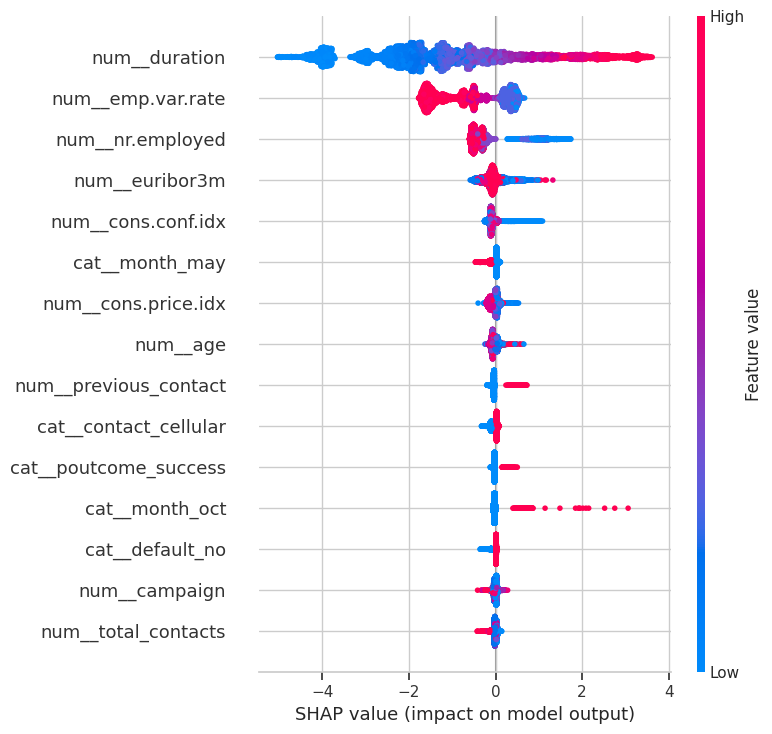

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    max_display=15
)

### Аналіз SHAP значень

SHAP аналіз дозволив визначити внесок окремих ознак у рішення моделі XGBoost.

Найбільший вплив має ознака `duration`, яка значно перевищує інші параметри. Це означає, що тривалість контакту з клієнтом є найбільш інформативною для прогнозування результату кампанії.

Також важливими виявились макроекономічні показники:
- `emp.var.rate`;
- `nr.employed`;
- `euribor3m`.

Отримані результати показують, що рішення моделі залежить не тільки від характеристик клієнта, а й від загальної економічної ситуації.

Водночас ознака `duration` потребує додаткового аналізу, оскільки вона може бути доступна лише після завершення контакту з клієнтом, що обмежує її використання для попереднього прогнозування.

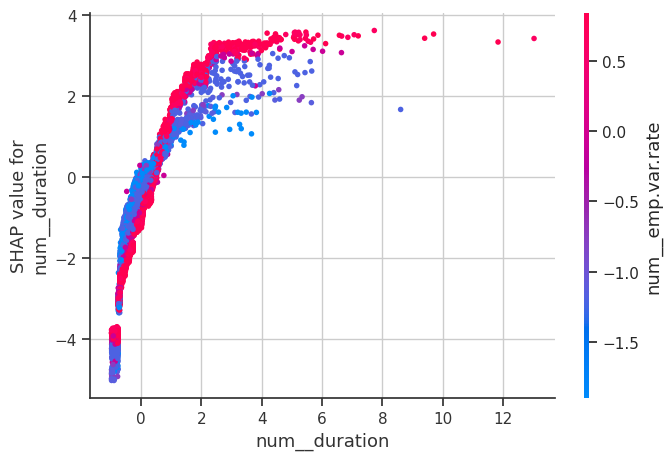

In [ ]:
shap.dependence_plot(
    "num__duration",
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

### SHAP dependence analysis для duration

Для детальнішого аналізу найбільш важливої ознаки було побудовано SHAP dependence plot для параметра `duration`.

Графік показує, що зі збільшенням тривалості контакту значення SHAP зростає. Це означає, що довші контакти мають позитивний вплив на прогноз моделі та збільшують ймовірність позитивного результату.

Найбільша зміна впливу спостерігається на початковому етапі збільшення тривалості контакту. Після певного значення вплив поступово стабілізується, що свідчить про нелінійну залежність між тривалістю контакту та результатом прогнозування.

Водночас варто враховувати, що ознака `duration` стає відомою лише після завершення контакту з клієнтом. Тому її висока важливість може частково відображати інформацію, яка недоступна на початковому етапі прогнозування.

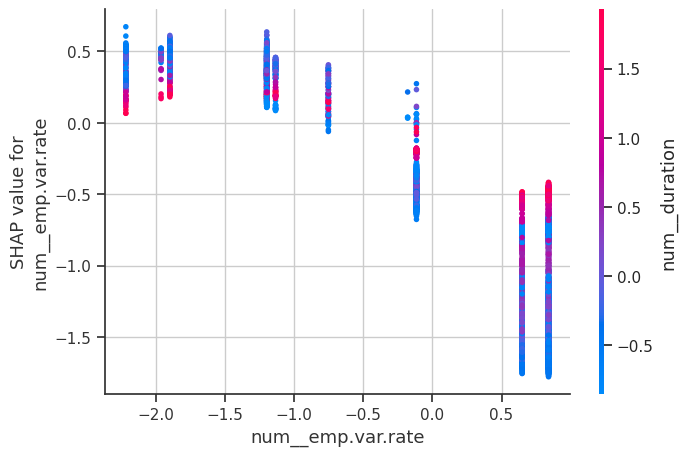

In [ ]:
shap.dependence_plot(
    "num__emp.var.rate",
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

### SHAP dependence analysis для emp.var.rate

Для аналізу впливу макроекономічних факторів було побудовано SHAP dependence plot для ознаки `emp.var.rate`.

Графік показує, що зміна значення `emp.var.rate` впливає на прогноз моделі, оскільки різні значення ознаки мають різний внесок у результат класифікації.

Це підтверджує, що економічне середовище є важливим фактором при прогнозуванні ймовірності оформлення депозиту клієнтом.

# Аналіз помилок моделі

Для аналізу помилок найкращої моделі XGBoost було використано Confusion Matrix.

Основні типи помилок:

- **False Positive** — модель передбачила відкриття депозиту, але клієнт його не відкрив.
- **False Negative** — модель не передбачила відкриття депозиту, хоча клієнт фактично його відкрив.

Наявність False Negative є найбільш критичною для задачі, оскільки такі випадки означають втрату потенційних клієнтів.

Можливі причини помилок:
- недостатня кількість інформації про клієнта;
- дисбаланс класів у датасеті;
- відсутність додаткових поведінкових ознак.

Для покращення моделі можна:
- оптимізувати поріг класифікації для збільшення Recall;
- використати методи балансування класів;
- додати нові ознаки через Feature Engineering;
- використати додаткові дані про поведінку клієнтів.

Таким чином, поточна модель XGBoost показує хороші результати, але її якість може бути покращена за рахунок роботи з помилками класифікації та розширення набору ознак.